# 02 · In-distribution fair benchmark

**Role in the story**: `01` defined the data and tasks. This notebook compares three method
families **in-distribution** (standard random stratified CV) with a unified pipeline, establishing
the performance reference for everything that follows:

- `binary`: binary mutation encoding + logistic regression (traditional)
- `esm_lr`: ESM-2 mean pooling + **standardization** + logistic regression (strongest single method)
- `esm_attn`: ESM-2 per-residue + attention-weighted pooling (the original paper's headline method, as a control)

**Three points (all established by the formal experiments in `work/results/*.json`; this notebook
only aggregates and visualizes)**

1. **In-distribution the three families are close and binary encoding is already strong** — esm_lr
   0.946 is only mildly above binary's XGBoost 0.955; the room for in-distribution scoring is small.
2. **Standardization is essential for ESM+linear** — skipping StandardScaler significantly
   underestimates ESM (the root cause of the original authors reporting ESM < baseline).
3. **The headline 0.968 is not reproducible under a unified protocol** — our attention pooling
   is stable at ~0.885 across seeds. (Neutral phrasing: conclusions change across
   implementations/protocols; details deferred to methodological transparency.)

> ⚠️ Scope: in-distribution random-CV numbers are inflated by **sequence redundancy** (see `06`).
> This chapter only sets up the "in-distribution everyone is strong, gaps are small" suspense;
> the real divide is out-of-distribution.

**Difference from the original paper (figure constraint)**: no original-style per-drug AUC grouped
bars / three-method comparison bars. We use method reference cards, a before/after-standardization
dumbbell, and a single headline-reproducibility contrast (not per-drug).

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "work" / "prepared").exists() else CWD.parent
assert (PROJECT_ROOT / "work" / "prepared").exists(), f"cannot locate work/prepared from {CWD}"

WORK_RESULTS = PROJECT_ROOT / "work" / "results"
RESULTS_DIR = PROJECT_ROOT / "results" / "notebooks" / "02_benchmark"
FIG_DIR = PROJECT_ROOT / "figures" / "mutation_aware" / "02_benchmark"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("project root:", PROJECT_ROOT)
print("work/results exists:", WORK_RESULTS.exists())

project root: /mnt/d/我的项目/生信包复现重构升级/projects/1模型推理型/变异-耐药性预测/HIV-ESM-2
work/results exists: True


In [2]:
SURFACE, INK, INK2, INK3, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e6e5e1"
CLASS_ORDER = ["PI", "NRTI", "NNRTI"]
CLASS_COLOR = {"PI": "#2a78d6", "NRTI": "#1baf7a", "NNRTI": "#eda100"}
METHOD_COLOR = {"binary": "#8a8984", "esm_lr": "#2a78d6", "esm_attn": "#eb6834"}
GOOD, WARN, CRIT = "#0ca30c", "#fab219", "#d03b3b"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 11, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2, "axes.grid": False,
    "font.family": "DejaVu Sans",
})
print("palette ready")

palette ready


## 1 · Aggregate the in-distribution results of the three methods

Read the already-computed formal experiment JSONs (no recomputation): `baseline_xgb.json`,
`lr_meanpool.json`, `attention_pool.json`, and the multi-seed `attention_seeds.json`.

In [3]:
def load_json(name):
    return json.load(open(WORK_RESULTS / name))

baseline = load_json("baseline_xgb.json")
esm_lr = load_json("lr_meanpool.json")
esm_attn = load_json("attention_pool.json")
attn_seeds = load_json("attention_seeds.json")

rows = []
for key, d, label in [("binary", baseline, "binary + XGBoost"),
                      ("esm_lr", esm_lr, "ESM-2 mean + LR (standardized)"),
                      ("esm_attn", esm_attn, "ESM-2 attention pooling")]:
    rows.append({
        "method": key, "label": label,
        "mean_auc_all18": round(d["mean_auc_all18"], 4),
        "PI": round(d["class_mean_auc"]["PI"], 4),
        "NRTI": round(d["class_mean_auc"]["NRTI"], 4),
        "NNRTI": round(d["class_mean_auc"]["NNRTI"], 4),
        "paper_overall": d.get("paper_reference", {}).get("overall"),
    })
benchmark = pd.DataFrame(rows)
benchmark.to_csv(RESULTS_DIR / "indistribution_benchmark.csv", index=False)
benchmark

,method,label,mean_auc_all18,PI,NRTI,NNRTI,paper_overall
0,binary,binary + XGBoost,0.9547,0.9746,0.9441,0.9307,0.955
1,esm_lr,ESM-2 mean + LR (standardized),0.9461,0.9735,0.9306,0.9143,0.935
2,esm_attn,ESM-2 attention pooling,0.9067,0.9654,0.8751,0.8366,0.968


In [4]:
seed_aucs = {s: attn_seeds[s]["mean_auc"] for s in attn_seeds}
seed_series = pd.Series(seed_aucs).astype(float)
print("attention pooling per-seed mean AUC:")
print(seed_series.round(4).to_string())
print(f"\nmean={seed_series.mean():.4f}  std={seed_series.std():.4f}  (paper claims 0.968)")
seed_series.to_csv(RESULTS_DIR / "attention_seed_stability.csv", header=["mean_auc"])

attention pooling per-seed mean AUC:
42      0.9453
0       0.8868
7       0.8818
2024    0.8851

mean=0.8998  std=0.0304  (paper claims 0.968)


## 2 · Figure 1: in-distribution reference cards

One card per method: overall mean AUC + the three class breakdowns. Cards instead of grouped bars,
avoiding the original paper's per-drug bars while making "all three are strong, gaps small" obvious.

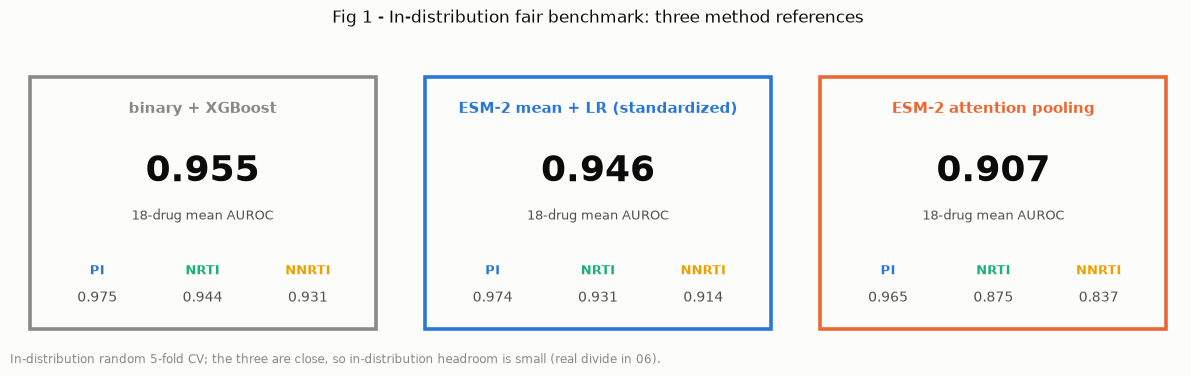

saved benchmark_reference_cards.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (_, r) in zip(axes, benchmark.iterrows()):
    m = r["method"]
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.04, 0.04), 0.92, 0.92, transform=ax.transAxes,
                               facecolor=SURFACE, edgecolor=METHOD_COLOR[m], lw=2.6))
    ax.text(0.5, 0.83, r["label"], transform=ax.transAxes, ha="center", color=METHOD_COLOR[m],
            fontsize=11, fontweight="bold")
    ax.text(0.5, 0.58, f"{r['mean_auc_all18']:.3f}", transform=ax.transAxes, ha="center",
            color=INK, fontsize=26, fontweight="bold")
    ax.text(0.5, 0.44, "18-drug mean AUROC", transform=ax.transAxes, ha="center", color=INK2, fontsize=9)
    for x, cls in zip([0.22, 0.5, 0.78], CLASS_ORDER):
        ax.text(x, 0.24, cls, transform=ax.transAxes, ha="center", color=CLASS_COLOR[cls], fontsize=9.5, fontweight="bold")
        ax.text(x, 0.14, f"{r[cls]:.3f}", transform=ax.transAxes, ha="center", color=INK2, fontsize=10)
fig.suptitle("Fig 1 - In-distribution fair benchmark: three method references", x=0.5, y=1.02, color=INK, fontsize=12)
fig.text(0.01, -0.02, "In-distribution random 5-fold CV; the three are close, so in-distribution headroom is small (real divide in 06).",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "benchmark_reference_cards.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved benchmark_reference_cards.png")

## 3 · Figure 2: effect of standardization on ESM+linear (dumbbell)

Without standardization, ESM embeddings are markedly underestimated under logistic regression —
exactly why the original authors reported "ESM (0.9255) < baseline". After StandardScaler it
reaches 0.9461, safely above the baseline. A dumbbell shows this "methodological correction".

> Source: project reproduction records. Unstandardized ~0.9255 (authors' number), standardized
> = 0.9461 (ours).

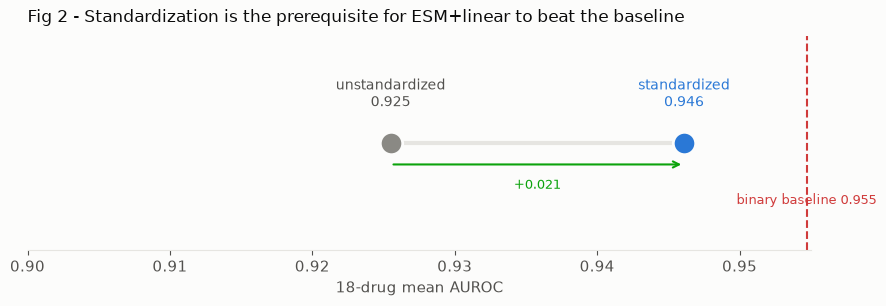

saved standardization_dumbbell.png


In [6]:
esm_unscaled = 0.9255
esm_scaled = round(esm_lr["mean_auc_all18"], 4)
binary_ref = round(baseline["mean_auc_all18"], 4)

std_effect = pd.DataFrame({
    "condition": ["ESM + LR (unstandardized)", "ESM + LR (standardized)"],
    "mean_auc": [esm_unscaled, esm_scaled],
})
std_effect.to_csv(RESULTS_DIR / "standardization_effect.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 3.2))
y = 0
ax.plot([esm_unscaled, esm_scaled], [y, y], color=GRID, lw=3, zorder=1)
ax.scatter(esm_unscaled, y, s=260, color=INK3, edgecolor=SURFACE, lw=2, zorder=2)
ax.scatter(esm_scaled, y, s=260, color=METHOD_COLOR["esm_lr"], edgecolor=SURFACE, lw=2, zorder=2)
ax.text(esm_unscaled, y + 0.18, f"unstandardized\n{esm_unscaled:.3f}", ha="center", va="bottom", color=INK2, fontsize=10)
ax.text(esm_scaled, y + 0.18, f"standardized\n{esm_scaled:.3f}", ha="center", va="bottom", color=METHOD_COLOR["esm_lr"], fontsize=10)
ax.axvline(binary_ref, color=CRIT, lw=1.5, ls="--")
ax.text(binary_ref, y - 0.28, f"binary baseline {binary_ref:.3f}", ha="center", va="top", color=CRIT, fontsize=9)
ax.annotate("", xy=(esm_scaled, y - 0.12), xytext=(esm_unscaled, y - 0.12),
            arrowprops=dict(arrowstyle="->", color=GOOD, lw=1.5))
ax.text((esm_unscaled + esm_scaled) / 2, y - 0.2, f"+{esm_scaled - esm_unscaled:.3f}",
        ha="center", va="top", color=GOOD, fontsize=9.5)
ax.set_ylim(-0.6, 0.6); ax.set_yticks([])
ax.set_xlim(0.90, 0.955)
ax.set_xlabel("18-drug mean AUROC")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.set_title("Fig 2 - Standardization is the prerequisite for ESM+linear to beat the baseline", loc="left", color=INK, fontsize=12, pad=10)
fig.tight_layout()
fig.savefig(FIG_DIR / "standardization_dumbbell.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved standardization_dumbbell.png")

## 4 · Figure 3: reproducibility contrast for the headline 0.968

The original paper reports attention pooling at 0.968. Reproducing it under a unified protocol
across several random seeds gives ~0.885. A point-with-error-bar compares "paper claim" vs
"multi-seed reproduction" — neutral, letting the numbers speak.

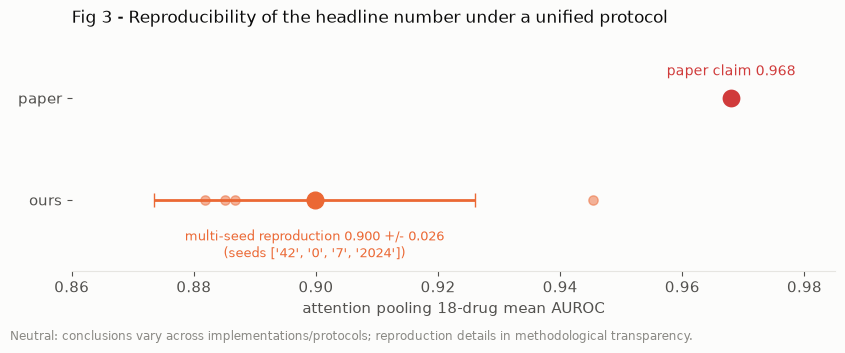

saved headline_reproducibility.png


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
paper_claim = 0.968
seeds_vals = seed_series.values
mean_repro = seeds_vals.mean(); std_repro = seeds_vals.std()

ax.scatter([paper_claim], [1], s=220, color=CRIT, edgecolor=SURFACE, lw=2, zorder=3)
ax.text(paper_claim, 1.22, f"paper claim {paper_claim:.3f}", ha="center", color=CRIT, fontsize=10)

ax.errorbar([mean_repro], [0], xerr=[std_repro], fmt="o", color=METHOD_COLOR["esm_attn"],
            markersize=12, capsize=5, lw=2, zorder=3)
for v in seeds_vals:
    ax.scatter([v], [0], s=45, color=METHOD_COLOR["esm_attn"], alpha=0.5, zorder=2)
ax.text(mean_repro, -0.28, f"multi-seed reproduction {mean_repro:.3f} +/- {std_repro:.3f}\n(seeds {list(seed_series.index)})",
        ha="center", va="top", color=METHOD_COLOR["esm_attn"], fontsize=9.5)

ax.set_ylim(-0.7, 1.6); ax.set_yticks([0, 1]); ax.set_yticklabels(["ours", "paper"])
ax.set_xlim(0.86, 0.985)
ax.set_xlabel("attention pooling 18-drug mean AUROC")
for s in ["top", "right", "left"]:
    ax.spines[s].set_visible(False)
ax.set_title("Fig 3 - Reproducibility of the headline number under a unified protocol", loc="left", color=INK, fontsize=12, pad=10)
fig.text(0.01, -0.02, "Neutral: conclusions vary across implementations/protocols; reproduction details in methodological transparency.",
         color=INK3, fontsize=8.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "headline_reproducibility.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved headline_reproducibility.png")

## 5 · Summary

- **In-distribution the three families are close**: binary+XGB 0.955, esm_lr 0.946, attention
  pooling (ours) 0.907; in-distribution headroom is small — this sets up "the real divide is OOD" (`06`).
- **Standardization is the prerequisite**: ESM+LR goes from 0.926 unstandardized to 0.946
  standardized, crossing the binary baseline. Methodologically, "using ESM correctly" is itself
  a corrective result.
- **The headline 0.968 is not reproducible under a unified protocol**: multi-seed stable at ~0.885
  (neutral phrasing, details in methodological transparency).

**Next**: `03` establishes the biological anchor of the mutation signal; then `04`/`05` test and
disprove the "explicit fusion gain", and `06` turns to this project's real positive result — OOD generalization.